# StyleFinder: A Two-Layer Fashion Information Retrieval System

**Layer 1:** Expert style recommendations based on body type and occasion  
**Layer 2:** Real product matching from a catalog of 44,000+ fashion items

In [2]:
%pip install --upgrade -q rank_bm25 sentence-transformers umap-learn datasets plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 149.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 52.6 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap

from collections import defaultdict, Counter, namedtuple
import math

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset
from IPython.display import display

## 1. Load the Datasets

Two datasets loaded from HuggingFace:
- **Fashion Style Instruct**: 3,190 style recommendations (body type + occasion -> outfit)
- **Fashion Product Images**: 44,000+ real products with names, categories, colors, etc.

In [4]:
# Layer 1: Style recommendations (body type + occasion -> outfit advice)
style_dataset = load_dataset("neuralwork/fashion-style-instruct", split="train")
style_df = style_dataset.to_pandas()
print(f"Style dataset shape: {style_df.shape}")
print(f"Columns: {style_df.columns.tolist()}")
style_df.head(2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/882 [00:00<?, ?B/s]

data/train-00000-of-00001-9b0ae8e510f95a(…):   0%|          | 0.00/2.64M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3193 [00:00<?, ? examples/s]

Style dataset shape: (3193, 3)
Columns: ['input', 'completion', 'context']


,input,completion,context
0,"I'm a tall, athletic man with broad shoulders ...",Outfit Combination 1:\n- Top: Fitted white lin...,I'm going to a nature retreat.
1,"I'm a medium height woman with a soft, round f...","Outfit 1:\n- Top: A loose, flowy peasant blous...",I'm going to a nature retreat.


In [5]:
# Layer 2: Real fashion products with names, categories, colors, etc.
product_dataset = load_dataset("ashraq/fashion-product-images-small", split="train")
product_df = product_dataset.to_pandas()
print(f"Product dataset shape: {product_df.shape}")
print(f"Columns: {product_df.columns.tolist()}")
product_df.head(5)

README.md:   0%|          | 0.00/867 [00:00<?, ?B/s]

data/train-00000-of-00002-6cff4c59f91661(…):   0%|          | 0.00/136M [00:00<?, ?B/s]

data/train-00001-of-00002-bb459e5ac5f01e(…):   0%|          | 0.00/135M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44072 [00:00<?, ? examples/s]

Product dataset shape: (44072, 11)
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...


## 2. Explore the Data

In [6]:
print("STYLE DATASET")
print(f"Total entries: {len(style_df)}")
print(f"\nExample INPUT (body + style):")
print(style_df['input'].iloc[0][:200])
print(f"\nExample CONTEXT (occasion):")
print(style_df['context'].iloc[0])
print(f"\nExample COMPLETION (outfit recommendation):")
print(style_df['completion'].iloc[0][:500])

STYLE DATASET
Total entries: 3193

Example INPUT (body + style):
I'm a tall, athletic man with broad shoulders and a narrow waist. I prefer sharp, tailored suits that highlight my V-shaped torso.

Example CONTEXT (occasion):
I'm going to a nature retreat.

Example COMPLETION (outfit recommendation):
Outfit Combination 1:
- Top: Fitted white linen shirt
- Bottom: Slim-fit beige chinos
- Shoe: Brown leather loafers
- Accessories: Brown woven belt, aviator sunglasses

Outfit Combination 2:
- Top: Light blue oxford button-down shirt
- Bottom: Navy blue tailored trousers
- Shoe: Tan leather brogues
- Accessories: Navy blue patterned pocket square, silver wristwatch

Outfit Combination 3:
- Top: Light gray tailored blazer
- Bottom: Dark wash denim jeans
- Shoe: White canvas sneakers
- Accessories


In [7]:
print("PRODUCT DATASET")
print(f"Total products: {len(product_df)}")

# Remove rows with missing key fields
product_df_clean = product_df.dropna(subset=['productDisplayName', 'articleType']).reset_index(drop=True)
print(f"Products after cleaning: {len(product_df_clean)}")

print(f"\nGender distribution:")
print(product_df_clean['gender'].value_counts())
print(f"\nTop 10 article types:")
print(product_df_clean['articleType'].value_counts().head(10))
print(f"\nUsage categories:")
print(product_df_clean['usage'].value_counts())
print(f"\nSeasons:")
print(product_df_clean['season'].value_counts())

print(f"\nExample product names:")
for i in range(5):
    print(f"  {product_df_clean['productDisplayName'].iloc[i]}")

PRODUCT DATASET
Total products: 44072
Products after cleaning: 44072

Gender distribution:
gender
Men       22104
Women     18357
Unisex     2126
Boys        830
Girls       655
Name: count, dtype: int64

Top 10 article types:
articleType
Tshirts         7065
Shirts          3212
Casual Shoes    2845
Watches         2542
Sports Shoes    2016
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Name: count, dtype: int64

Usage categories:
usage
Casual          34392
Sports           4004
Ethnic           3208
Formal           2345
Smart Casual       67
Party              29
Travel             26
Home                1
Name: count, dtype: int64

Seasons:
season
Summer    21438
Fall      11414
Winter     8509
Spring     2711
Name: count, dtype: int64

Example product names:
  Turtle Check Men Navy Blue Shirt
  Peter England Men Party Blue Jeans
  Titan Women Silver Watch
  Manchester United Men Solid Black Track Pants
  Puma Men Grey T-sh

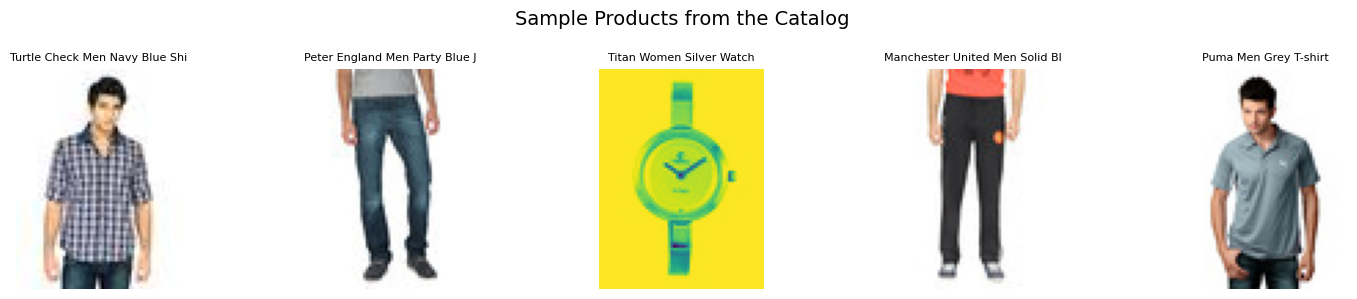

In [8]:
# Preview some product images from the dataset
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    row = product_df_clean.iloc[i]
    img = product_dataset[int(product_df_clean.iloc[i].name)]['image']
    ax.imshow(img)
    ax.set_title(row['productDisplayName'][:30], fontsize=8)
    ax.axis('off')
plt.suptitle("Sample Products from the Catalog", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Build the Index

*For products, we combine all text metadata fields (gender, category, article type, color, season, usage, and product name) into a single searchable text field. This is the text-based indexing strategy, images are available in the dataset but indexing and retrieval are performed on text only.*

In [9]:
Doc = namedtuple('Doc', ['doc_id', 'text'])

# --- Style docs: combine input + context + completion into one document ---
style_docs = []
for idx, row in style_df.iterrows():
    text = f"Body: {row['input']}. Occasion: {row['context']}. Recommendation: {row['completion']}"
    style_docs.append(Doc(doc_id=str(idx), text=text))

print(f"# of style documents: {len(style_docs)}")

# --- Product docs: combine metadata fields into a rich text document ---
product_docs = []
for idx, row in product_df_clean.iterrows():
    parts = []
    for field in ['gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'usage']:
        val = row.get(field)
        if pd.notna(val):
            parts.append(str(val))
    name = str(row['productDisplayName'])
    text = " ".join(parts) + " - " + name
    product_docs.append(Doc(doc_id=str(idx), text=text))

print(f"# of product documents: {len(product_docs)}")

# of style documents: 3193
# of product documents: 44072


In [10]:
print("STYLE DOC EXAMPLE")
print(style_docs[0].doc_id, style_docs[0].text[:300])
print()
print("PRODUCT DOC EXAMPLES")
for doc in product_docs[:5]:
    print(doc.doc_id, doc.text)

STYLE DOC EXAMPLE
0 Body: I'm a tall, athletic man with broad shoulders and a narrow waist. I prefer sharp, tailored suits that highlight my V-shaped torso.. Occasion: I'm going to a nature retreat.. Recommendation: Outfit Combination 1:
- Top: Fitted white linen shirt
- Bottom: Slim-fit beige chinos
- Shoe: Brown leat

PRODUCT DOC EXAMPLES
0 Men Apparel Topwear Shirts Navy Blue Fall Casual - Turtle Check Men Navy Blue Shirt
1 Men Apparel Bottomwear Jeans Blue Summer Casual - Peter England Men Party Blue Jeans
2 Women Accessories Watches Watches Silver Winter Casual - Titan Women Silver Watch
3 Men Apparel Bottomwear Track Pants Black Fall Casual - Manchester United Men Solid Black Track Pants
4 Men Apparel Topwear Tshirts Grey Summer Casual - Puma Men Grey T-shirt


## Tokenizer and Inverted Index

In [11]:
def simple_tokenize(text: str):
    return text.lower().split()

assert simple_tokenize("Hello World") == ["hello", "world"]

In [12]:
#  Style Index
style_inverted_index = defaultdict(list)
style_corpus = {}

for doc in style_docs:
    style_corpus[doc.doc_id] = doc.text
    tokens = simple_tokenize(doc.text)
    unique_tokens = set(tokens)
    for token in unique_tokens:
        style_inverted_index[token].append(doc.doc_id)

print(f"Style index: {len(style_inverted_index)} unique terms.")

# Product Index
product_inverted_index = defaultdict(list)
product_corpus = {}

for doc in product_docs:
    product_corpus[doc.doc_id] = doc.text
    tokens = simple_tokenize(doc.text)
    unique_tokens = set(tokens)
    for token in unique_tokens:
        product_inverted_index[token].append(doc.doc_id)

print(f"Product index: {len(product_inverted_index)} unique terms.")

Style index: 7115 unique terms.
Product index: 8868 unique terms.


## Boolean Search

In [13]:
def boolean_search(query, index):
    query_tokens = simple_tokenize(query)
    if not query_tokens:
        return []

    results = set(index.get(query_tokens[0], []))
    for token in query_tokens[1:]:
        results = results.intersection(set(index.get(token, [])))

    return list(results)

# Test on products
sample_query = "black formal shoes"
hits = boolean_search(sample_query, product_inverted_index)
print(f"Boolean hits for '{sample_query}': {len(hits)}")
for pid in hits[:5]:
    print(f"  {product_corpus[pid]}")

Boolean hits for 'black formal shoes': 422
  Men Footwear Shoes Formal Shoes Black Summer Formal - Franco Leone Men Black Slip On Formal Shoes
  Men Footwear Shoes Formal Shoes Black Winter Formal - Lee Cooper Men's Formal Simpleton Black Shoe
  Men Footwear Shoes Formal Shoes Black Summer Formal - Franco Leone Men Black Formal Shoes
  Men Footwear Shoes Formal Shoes Black Summer Formal - Rockport Men's Aderner Black Shoe
  Men Footwear Shoes Formal Shoes Black Summer Formal - Franco Leone Men Formal Black Formal Shoes


## BM25 Retrieval

In [14]:
# Style BM25
style_tokenized = [simple_tokenize(doc.text) for doc in style_docs]
style_bm25 = BM25Okapi(style_tokenized)

def bm25_search_styles(query, n=5):
    tokenized_query = simple_tokenize(query)
    scores = style_bm25.get_scores(tokenized_query)
    top_n_indices = scores.argsort()[-n:][::-1]
    return [style_docs[i] for i in top_n_indices]

#  Product BM25
product_tokenized = [simple_tokenize(doc.text) for doc in product_docs]
product_bm25 = BM25Okapi(product_tokenized)

def bm25_search_products(query, n=5):
    tokenized_query = simple_tokenize(query)
    scores = product_bm25.get_scores(tokenized_query)
    top_n_indices = scores.argsort()[-n:][::-1]
    return [product_docs[i] for i in top_n_indices]

# Test
print("BM25 Product Search: 'black formal dress women'")
results = bm25_search_products("black formal dress women")
for i, res in enumerate(results):
    print(f"Rank {i+1}: {res.text}")

BM25 Product Search: 'black formal dress women'
Rank 1: Women Apparel Dress Dresses Black Fall Formal - Avirate Black Formal Dress
Rank 2: Women Apparel Dress Dresses Navy Blue Summer Formal - French Connection Women Navy Blue Dress
Rank 3: Women Apparel Dress Dresses Black Fall Party - Avirate Black Dress
Rank 4: Women Apparel Dress Dresses Black Fall Party - Avirate Black Dress
Rank 5: Women Apparel Dress Dresses Black Fall Party - Avirate Black Dress


## Semantic Embedding with Sentence Transformers

In [15]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
style_texts = [doc.text for doc in style_docs]
style_embeddings = model.encode(style_texts, show_progress_bar=True)
print(f"Style Embedding Shape: {style_embeddings.shape}")

product_texts = [doc.text for doc in product_docs]
product_embeddings = model.encode(product_texts, show_progress_bar=True, batch_size=64)
print(f"Product Embedding Shape: {product_embeddings.shape}")

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Style Embedding Shape: (3193, 384)


Batches:   0%|          | 0/689 [00:00<?, ?it/s]

Product Embedding Shape: (44072, 384)


In [17]:
def semantic_search_styles(query, n=5):
    query_embedding = model.encode(query)
    scores = util.cos_sim(query_embedding, style_embeddings)[0]
    top_n = scores.argsort(descending=True)[:n]
    return [(style_docs[i], scores[i].item()) for i in top_n]

def semantic_search_products(query, n=5):
    query_embedding = model.encode(query)
    scores = util.cos_sim(query_embedding, product_embeddings)[0]
    top_n = scores.argsort(descending=True)[:n]
    return [(product_docs[i], scores[i].item()) for i in top_n]

# Test
print("Semantic Product Search: 'elegant black evening dress'")
results = semantic_search_products("elegant black evening dress")
for i, (doc, score) in enumerate(results):
    print(f"Rank {i+1} (score: {score:.4f}): {doc.text}")

Semantic Product Search: 'elegant black evening dress'
Rank 1 (score: 0.7624): Women Apparel Dress Dresses Black Summer Casual - Forever New Women's Top Black Dress
Rank 2 (score: 0.7524): Women Apparel Dress Dresses Black Summer Casual - Forever New Women's Lacy Black Dress
Rank 3 (score: 0.7358): Women Apparel Dress Dresses Black Summer Casual - Forever New Women's Gold Sleeveless Black Dress
Rank 4 (score: 0.7148): Women Apparel Dress Dresses Black Fall Casual - Avirate Black Dress
Rank 5 (score: 0.7148): Women Apparel Dress Dresses Black Fall Casual - Avirate Black Dress


In [18]:
test_sentences = [
    "women red wrap dress formal event",
    "ladies crimson draped gown cocktail party",
    "men blue casual running shoes sports",
]

test_embeddings = model.encode(test_sentences)

sim_fashion = util.cos_sim(test_embeddings[0], test_embeddings[1])
sim_mixed = util.cos_sim(test_embeddings[0], test_embeddings[2])

print(f"Similarity (red wrap dress vs crimson gown): {sim_fashion.item():.4f}")
print(f"Similarity (red wrap dress vs running shoes): {sim_mixed.item():.4f}")

Similarity (red wrap dress vs crimson gown): 0.4786
Similarity (red wrap dress vs running shoes): 0.0720


## UMAP Visualization

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


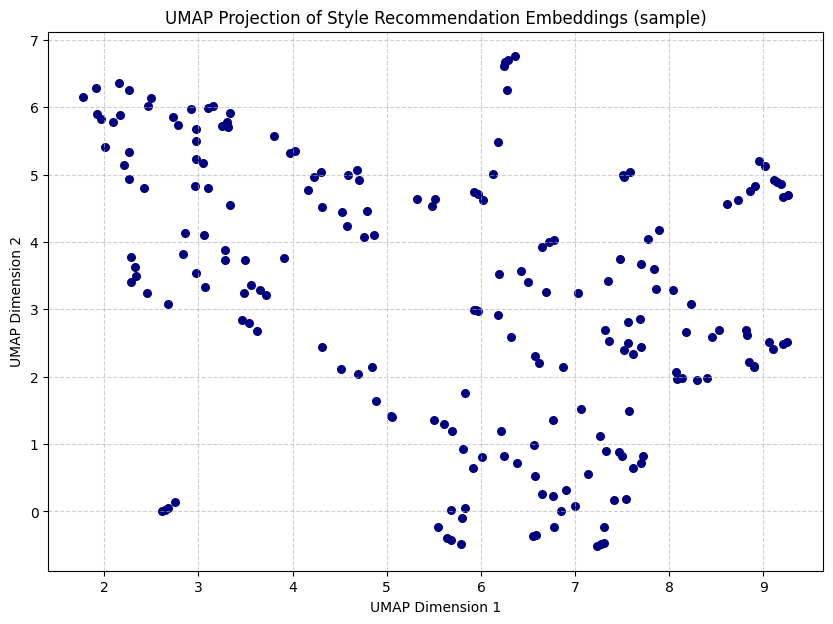

In [19]:
sample_size = min(200, len(style_docs))
sample_indices = np.random.choice(len(style_docs), sample_size, replace=False)
sample_embeddings_umap = style_embeddings[sample_indices]

reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(sample_embeddings_umap)

plt.figure(figsize=(10, 7))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], color='navy', s=30)
plt.title("UMAP Projection of Style Recommendation Embeddings (sample)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


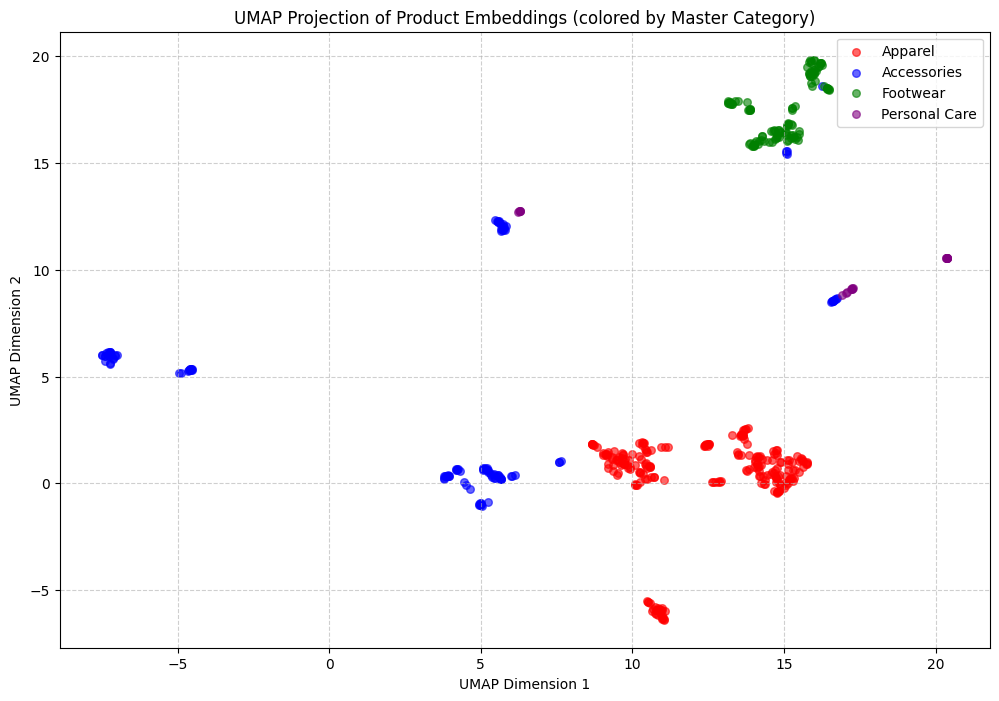

In [20]:
sample_size_prod = min(500, len(product_docs))
sample_prod_indices = np.random.choice(len(product_docs), sample_size_prod, replace=False)
sample_prod_embeddings = product_embeddings[sample_prod_indices]

reducer2 = umap.UMAP(n_neighbors=10, min_dist=0.1, n_components=2, random_state=42)
prod_2d = reducer2.fit_transform(sample_prod_embeddings)

categories = [product_df_clean.iloc[i]['masterCategory'] for i in sample_prod_indices]
cat_colors = {
    'Apparel': 'red', 'Accessories': 'blue', 'Footwear': 'green',
    'Personal Care': 'purple', 'Free Items': 'orange',
    'Sporting Goods': 'brown', 'Home': 'pink'
}

plt.figure(figsize=(12, 8))
for cat in cat_colors:
    mask = [c == cat for c in categories]
    if any(mask):
        pts = prod_2d[mask]
        plt.scatter(pts[:, 0], pts[:, 1], c=cat_colors[cat], label=cat, s=30, alpha=0.6)

plt.legend()
plt.title("UMAP Projection of Product Embeddings (colored by Master Category)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
import plotly.express as px

sample_labels = []
for i in sample_indices:
    inp = style_df.iloc[i]['input'][:60]
    ctx = style_df.iloc[i]['context'][:40]
    sample_labels.append(f"{inp}... | {ctx}")

fig = px.scatter(
    x=embedding_2d[:, 0],
    y=embedding_2d[:, 1],
    hover_name=sample_labels,
    title="UMAP - Style Recommendations (hover to see details)"
)
fig.show()

## The Complete System: StyleFinder

A two-layer IR system:
- **Layer 1** uses semantic search on the style dataset to find outfit recommendations matching the user's body type, style, and occasion.
- **Layer 2** uses semantic search on the product catalog to find real products that match the recommended outfit pieces.

Product images from the dataset are displayed alongside text results as a visual aid, but all indexing and retrieval is performed on text fields only.

In [22]:
def stylefinder(query, n_styles=3, n_products=5):
    """
    Two-layer IR system:
    Layer 1: Finds outfit recommendations based on body profile + occasion
    Layer 2: Finds real products matching the recommended outfit pieces
    """

    print(f"STYLEFINDER QUERY: {query}")

    # LAYER 1: Style Recommendations
    print(f"\nLAYER 1: Style Recommendations")

    style_results = semantic_search_styles(query, n=n_styles)

    for i, (doc, score) in enumerate(style_results):
        row = style_df.iloc[int(doc.doc_id)]
        print(f"\n  Recommendation {i+1} (score: {score:.4f}):")
        print(f"  Profile: {row['input'][:120]}...")
        print(f"  Occasion: {row['context']}")
        completion = row['completion']
        first_end = completion.find("Outfit Combination 2")
        if first_end == -1:
            first_end = completion.find("Outfit 2")
        if first_end == -1:
            first_end = completion.find("2. Outfit")
        if first_end == -1:
            first_end = 500
        print(f"  Top Outfit: {completion[:first_end].strip()}")

    # LAYER 2: Product Search with Images
    print(f"\n\n LAYER 2: Matching Products")

    best_style = style_df.iloc[int(style_results[0][0].doc_id)]
    recommendation_text = best_style['completion'][:300]
    product_query = query + " " + recommendation_text

    product_results = semantic_search_products(product_query, n=n_products)

    # Display products with images
    fig, axes = plt.subplots(1, n_products, figsize=(3 * n_products, 3.5))
    if n_products == 1:
        axes = [axes]

    for i, (doc, score) in enumerate(product_results):
        row = product_df_clean.iloc[int(doc.doc_id)]
        print(f"\n  Product {i+1} (score: {score:.4f}):")
        print(f"  Name: {row['productDisplayName']}")
        print(f"  Type: {row['articleType']} | Color: {row['baseColour']} | Season: {row['season']} | Usage: {row['usage']}")

        # Show product image from original dataset
        img = product_dataset[int(product_df_clean.iloc[int(doc.doc_id)].name)]['image']
        axes[i].imshow(img)
        axes[i].set_title(f"{row['productDisplayName'][:25]}...\nscore: {score:.3f}", fontsize=8)
        axes[i].axis('off')

    plt.suptitle(f"Products for: {query[:60]}...", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return style_results, product_results

## Testing the StyleFinder

STYLEFINDER QUERY: I have an hourglass figure and I am looking for something elegant to wear to a summer wedding

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.6232):
  Profile: I'm a curvy ruler shape who likes sleek, modern fashion. I want to create more of an hourglass silhouette by accentuatin...
  Occasion: I'm going to a cruise.
  Top Outfit: Outfit Combination 1:
- Top: A fitted off-shoulder blouse in a bold color like royal blue or fuchsia.
- Bottom: A high-waisted, wide-leg pant in a crisp white or black color.
- Shoe: Pair this outfit with some open-toe heeled sandals in a metallic shade like silver or rose gold.
- Accessories: Add a statement belt in a contrasting color to cinch in your waist and complete the hourglass silhouette. Finish off the look with some oversized sunglasses and a sleek clutch.

  Recommendation 2 (score: 0.6167):
  Profile: I'm a compact, muscular woman with an hourglass figure. I opt for fitted, stretchy fabrics that showcase my toned 

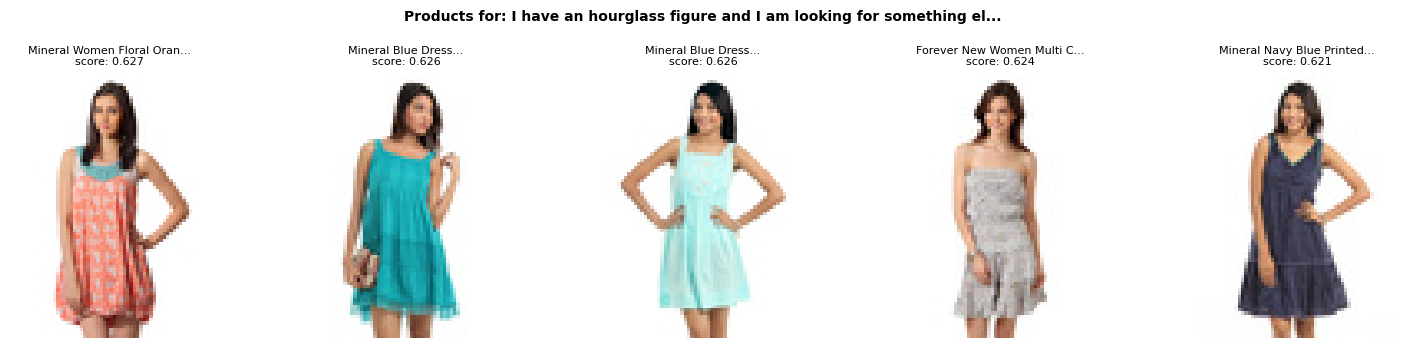

([(Doc(doc_id='1852', text="Body: I'm a curvy ruler shape who likes sleek, modern fashion. I want to create more of an hourglass silhouette by accentuating my narrow waist.. Occasion: I'm going to a cruise.. Recommendation: Outfit Combination 1:\n- Top: A fitted off-shoulder blouse in a bold color like royal blue or fuchsia.\n- Bottom: A high-waisted, wide-leg pant in a crisp white or black color.\n- Shoe: Pair this outfit with some open-toe heeled sandals in a metallic shade like silver or rose gold.\n- Accessories: Add a statement belt in a contrasting color to cinch in your waist and complete the hourglass silhouette. Finish off the look with some oversized sunglasses and a sleek clutch.\n\nOutfit Combination 2:\n- Top: A wrap-style, V-neck top in a vibrant pattern such as floral or tropical print.\n- Bottom: Go for a high-waisted skirt in a flowy fabric like chiffon or silk. Opt for a skirt with a slight flare to create movement and enhance your curves.\n- Shoe: Choose a pair of st

In [23]:
# Query 1: Wedding guest
stylefinder("I have an hourglass figure and I am looking for something elegant to wear to a summer wedding")

STYLEFINDER QUERY: I am a plus-size woman preparing for a job interview and I want to look polished and confident

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.6218):
  Profile: I'm a plus-size woman with thick arms and legs who loves Old Hollywood glamour. I need dress options that gracefully dra...
  Occasion: I'm going to a job interview.
  Top Outfit: Outfit Combination 1:

- Top: A classic black blouse with a draped neckline that highlights your upper body and adds a touch of elegance. Look for a style with slightly longer sleeves to provide coverage for your arms.
- Bottom: A high-waisted pencil skirt in a rich jewel tone, such as emerald green or royal blue. This will accentuate your curves while elongating your legs.
- Shoes: Pair the outfit with a pair of black, closed-toe high heels to add height and sophistication.
- Accessories: Add a statement belt in a metallic finish to cinch in your waist and create a defined silhouette. Complete the look with some delic

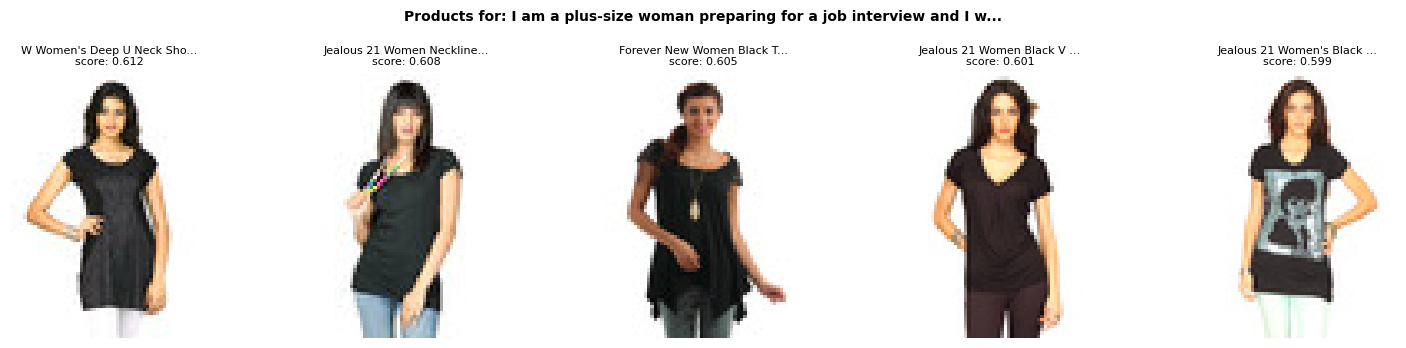

([(Doc(doc_id='1219', text="Body: I'm a plus-size woman with thick arms and legs who loves Old Hollywood glamour. I need dress options that gracefully drape over my soft, heavyset figure.. Occasion: I'm going to a job interview.. Recommendation: Outfit Combination 1:\n\n- Top: A classic black blouse with a draped neckline that highlights your upper body and adds a touch of elegance. Look for a style with slightly longer sleeves to provide coverage for your arms.\n- Bottom: A high-waisted pencil skirt in a rich jewel tone, such as emerald green or royal blue. This will accentuate your curves while elongating your legs.\n- Shoes: Pair the outfit with a pair of black, closed-toe high heels to add height and sophistication.\n- Accessories: Add a statement belt in a metallic finish to cinch in your waist and create a defined silhouette. Complete the look with some delicate gold hoop earrings and a structured black handbag.\n\nOutfit Combination 2:\n\n- Top: Opt for a flowy, draped wrap blou

In [24]:
# Query 2: Job interview
stylefinder("I am a plus-size woman preparing for a job interview and I want to look polished and confident")

STYLEFINDER QUERY: I am a tall man with broad shoulders looking for a casual outfit for a weekend brunch

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.6496):
  Profile: I'm a tall man at 6'0 with a thin rectangular body shape. I love fashionable clothes but have trouble finding things lik...
  Occasion: I'm going to a casual date.
  Top Outfit: Outfit 1:
- Top: A fitted button-up shirt in a bold color like burgundy or navy. Roll up the sleeves slightly for a relaxed look.
- Bottom: Slim-fit chinos in a neutral color like khaki or charcoal gray. Make sure they have a longer inseam to accommodate your long legs.
- Shoes: Finish the outfit with a pair of suede Chelsea boots in a coordinating color.
- Accessories: Add a leather belt in a complementary shade and a sleek watch for a polished touch.

  Recommendation 2 (score: 0.6475):
  Profile: I'm a tall, willowy man with long limbs who prefers refined, tailored looks. I need help finding properly fitted shirts,...
  Occasi

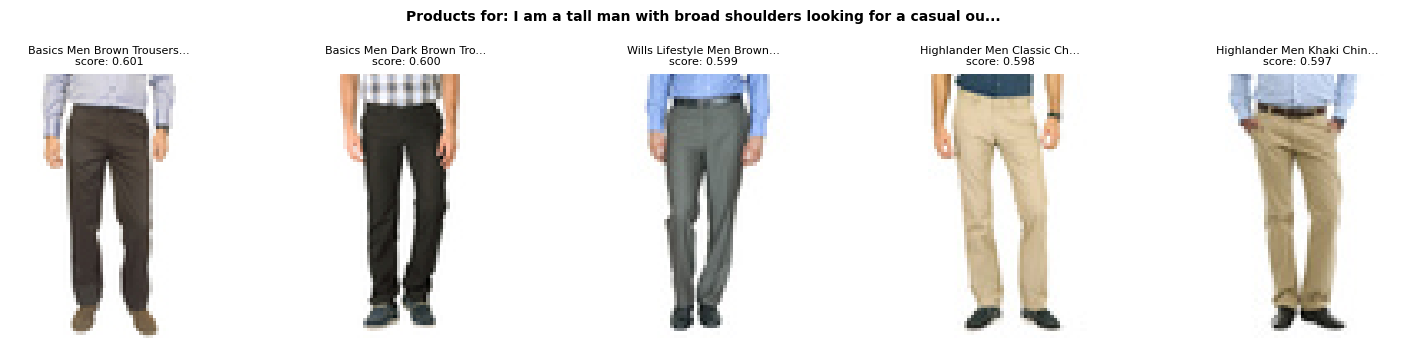

([(Doc(doc_id='2086', text="Body: I'm a tall man at 6'0 with a thin rectangular body shape. I love fashionable clothes but have trouble finding things like suits and jeans that fit my long limbs well.. Occasion: I'm going to a casual date.. Recommendation: Outfit 1:\n- Top: A fitted button-up shirt in a bold color like burgundy or navy. Roll up the sleeves slightly for a relaxed look.\n- Bottom: Slim-fit chinos in a neutral color like khaki or charcoal gray. Make sure they have a longer inseam to accommodate your long legs.\n- Shoes: Finish the outfit with a pair of suede Chelsea boots in a coordinating color.\n- Accessories: Add a leather belt in a complementary shade and a sleek watch for a polished touch.\n\nOutfit 2:\n- Top: Opt for a well-fitting, short-sleeved Henley in a soft material like cotton or linen. Look for one in a charcoal gray or deep navy shade.\n- Bottom: Go for dark wash slim jeans with a longer inseam to cater to your height.\n- Shoes: Choose a pair of clean white

In [25]:
# Query 3: Casual brunch
stylefinder("I am a tall man with broad shoulders looking for a casual outfit for a weekend brunch")

STYLEFINDER QUERY: I am a skinny non-binary person who prefers minimalist gender-neutral clothing for an art exhibition

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.6520):
  Profile: I'm a busty, hourglass cis woman who prefers gender-neutral styles. I want to minimize my curves for a more androgynous ...
  Occasion: I'm going to a city tour.
  Top Outfit: Outfit recommendation 1: 

- Top: Oversized button-up shirt in a neutral color (e.g. white or light blue)
- Bottom: Slim-fit or straight-leg trousers in a dark shade (e.g. black or navy)
- Shoes: Low-top sneakers in a contrasting color (e.g. white or gray)
- Accessories: A minimalist belt and a chunky watch

This outfit choice balances a more masculine silhouette with a touch of femininity by wearing an oversized shirt to minimize your curves. The dark trousers create a streamlined look, while t

  Recommendation 2 (score: 0.6498):
  Profile: I'm a tall, slender, androgynous person. I lean towards gender-neutral, min

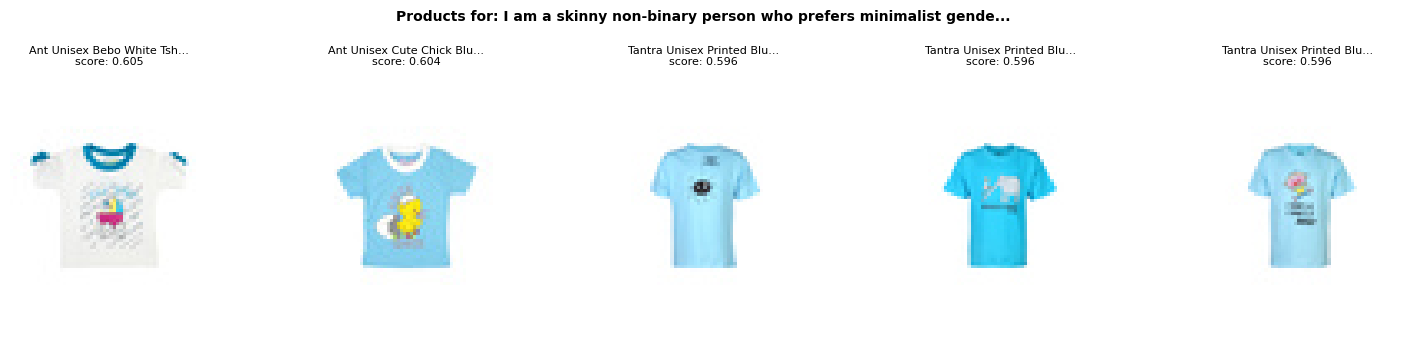

([(Doc(doc_id='1296', text="Body: I'm a busty, hourglass cis woman who prefers gender-neutral styles. I want to minimize my curves for a more androgynous look.. Occasion: I'm going to a city tour.. Recommendation: Outfit recommendation 1: \n\n- Top: Oversized button-up shirt in a neutral color (e.g. white or light blue)\n- Bottom: Slim-fit or straight-leg trousers in a dark shade (e.g. black or navy)\n- Shoes: Low-top sneakers in a contrasting color (e.g. white or gray)\n- Accessories: A minimalist belt and a chunky watch\n\nThis outfit choice balances a more masculine silhouette with a touch of femininity by wearing an oversized shirt to minimize your curves. The dark trousers create a streamlined look, while the low-top sneakers bring in a casual, gender-neutral element.\n\nOutfit recommendation 2: \n\n- Top: Loose-fitting, sleeveless tunic in a muted tone (e.g. olive green or beige)\n- Bottom: Cropped, wide-legged pants in a neutral color (e.g. khaki or taupe)\n- Shoes: Slip-on loaf

In [26]:
# Query 4: Art exhibition
stylefinder("I am a skinny non-binary person who prefers minimalist gender-neutral clothing for an art exhibition")

STYLEFINDER QUERY: I need a comfortable and practical outfit for hiking in cool weather

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.7519):
  Profile: I'm a plus-size, tall woman with a strong, athletic build. I enjoy elegant, structured clothing that highlights my stron...
  Occasion: I'm going to a camping / hiking.
  Top Outfit: 1. Outfit combination:
- Top: A loose-fitting, sleeveless tank top in a breathable fabric like linen or cotton. Look for a top with a bit of structure, such as a square neckline or wide shoulder straps to highlight your athletic build.
- Bottom: Opt for a pair of high-waisted, wide-leg pants in a durable fabric like denim or twill. These will provide comfort and coverage during hiking activities.
- Shoe: Choose a pair of sturdy hiking boots with ankle support and a thick sole for added stability on trails.
- Accessories: Bring a wide-brimmed hat to shield you from the sun, a small backpack to carry your essentials, and a pair of sunglasses t

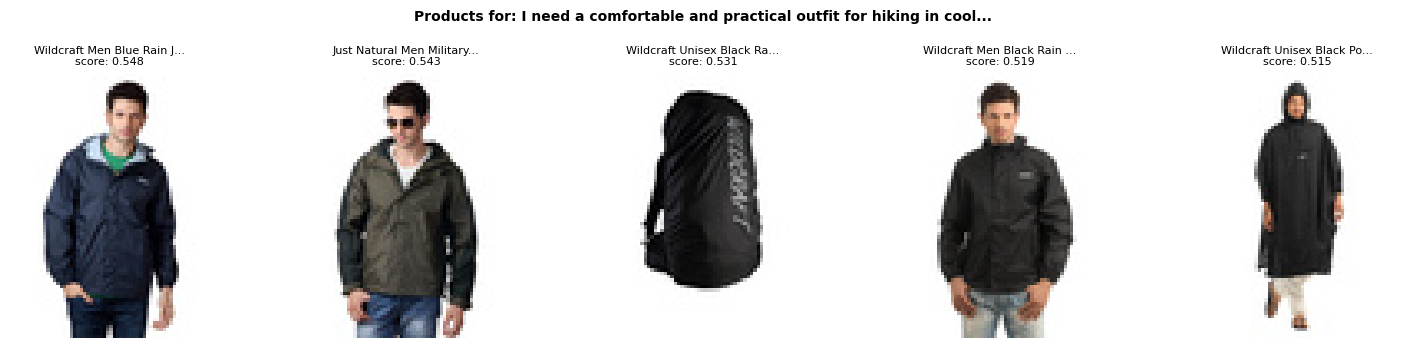

In [27]:
# Query 5: Hiking
stylefinder("I need a comfortable and practical outfit for hiking in cool weather");

## Comparison: BM25 vs Semantic Search on 10 Evaluation Queries

We test 7 realistic queries and 3 adversarial queries designed to expose system limitations.

In [28]:
queries = [
    # Realistic queries
    "flattering wedding guest dress that cinches at the waist",
    "plus-size woman looking for professional interview outfit",
    "tall athletic man going to a casual date night",
    "non-binary person minimalist outfit for a gallery opening",
    "pear-shaped woman looking for a brunch outfit",
    "comfortable hiking outfit for cool autumn weather",
    "hourglass figure looking for an elegant evening gown",
    # Adversarial queries (test system limits)
    "outfit for wheelchair user at a formal event",
    "budget friendly outfit under 50 dollars",
    "sustainable eco-friendly clothing for a date night",
]

print("COMPARISON: BM25 vs SEMANTIC SEARCH")

for q in queries:
    print(f"QUERY: {q}")

    # Boolean
    bool_hits_style = boolean_search(q, style_inverted_index)
    bool_hits_product = boolean_search(q, product_inverted_index)
    print(f"\nBoolean hits -> Styles: {len(bool_hits_style)} | Products: {len(bool_hits_product)}")

    # BM25 Style Top 1
    print(f"\n BM25 Style Top 1")
    bm25_res = bm25_search_styles(q, n=1)
    for res in bm25_res:
        print(f"  {res.text[:150]}...")

    # Semantic Style Top 1
    print(f"\n Semantic Style Top 1")
    sem_res = semantic_search_styles(q, n=1)
    for doc, score in sem_res:
        print(f"  (score: {score:.4f}): {doc.text[:150]}...")

    # BM25 Product Top 3
    print(f"\n BM25 Product Top 3")
    bm25_prod = bm25_search_products(q, n=3)
    for i, res in enumerate(bm25_prod):
        print(f"  {i+1}. {res.text}")

    # Semantic Product Top 3
    print(f"\n Semantic Product Top 3")
    sem_prod = semantic_search_products(q, n=3)
    for i, (doc, score) in enumerate(sem_prod):
        print(f"  {i+1}. (score: {score:.4f}): {doc.text}")

COMPARISON: BM25 vs SEMANTIC SEARCH
QUERY: flattering wedding guest dress that cinches at the waist

Boolean hits -> Styles: 0 | Products: 0

 BM25 Style Top 1
  Body: I'm a tall woman at 5'10 with a ruler-straight figure. I want feminine styles that add curves to my rectangle shape.I'm a cis woman who is 6'0 w...

 Semantic Style Top 1
  (score: 0.6926): Body: I'm a medium-height woman with a narrow waist and wider hips. I prefer elegant, form-fitting dresses that emphasize my curves.. Occasion: I'm go...

 BM25 Product Top 3
  1. Unisex Accessories Bags Waist Pouch Blue Winter Casual - Wildcraft Unisex Blue Waist pouch
  2. Unisex Accessories Bags Waist Pouch Red Winter Casual - Wildcraft Unisex Red Waist Pouch
  3. Unisex Accessories Bags Waist Pouch Pink Winter Casual - Wildcraft Unisex Pink Waist Pouch

 Semantic Product Top 3
  1. (score: 0.5372): Women Apparel Dress Dresses Cream Fall Casual - Forever New Women Champagne Dresses
  2. (score: 0.5367): Women Apparel Dress Dresses 

## Other Query Testings

These queries test concepts absent from the datasets: wheelchair accessibility, budget constraints, and sustainability. The system should ideally indicate low confidence, but instead returns results with misleadingly high scores.

STYLEFINDER QUERY: outfit for wheelchair user at a formal event

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.4418):
  Profile: I'm a tall, slender, androgynous person. I lean towards gender-neutral, minimalist styles that flatter my linear silhoue...
  Occasion: I'm going to a national parks.
  Top Outfit: Outfit Combination 1:
- Top: A loose-fitting short-sleeve button-up shirt in a neutral color like beige or army green.
- Bottom: High-waisted wide-leg pants in a lightweight fabric like linen or cotton, in a complementary neutral color like white or navy blue.
- Shoes: Slip-on canvas sneakers in a neutral shade like gray or black.
- Accessories: A wide-brimmed straw hat for sun protection, a minimalist leather belt, and a canvas tote bag to carry your essentials.

  Recommendation 2 (score: 0.4389):
  Profile: I'm a tall, curvy woman with a defined waist. I love retro-inspired styles, especially fit-and-flare dresses that highli...
  Occasion: I'm going to a music fe

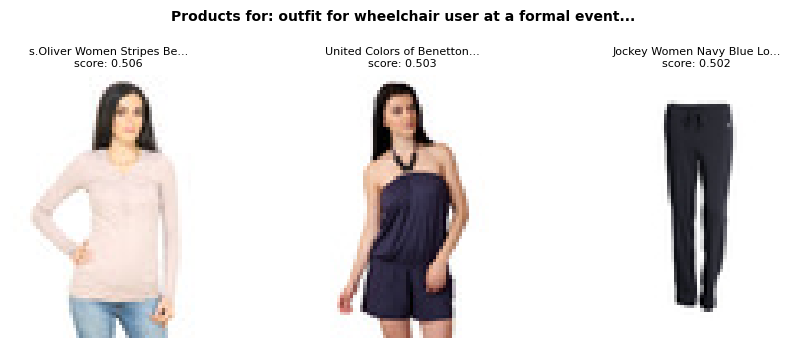

STYLEFINDER QUERY: budget friendly outfit under 50 dollars

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.6104):
  Profile: I have a long, gangly build but gravitate toward refined preppy looks. I want recommendations on properly fitted blazers...
  Occasion: I'm going to a city tour.
  Top Outfit: Outfit Combination 1:
- Top: Crisp white button-down shirt with a slim fit. Look for a longer length to accommodate your tall frame.
- Bottom: Tailored navy blue trousers with a slim leg. Opt for a mid-rise waist to balance out your proportions.
- Shoe: Brown leather loafers. Choose a pair with a sleek design to further enhance your refined preppy look.
- Accessories: Complete the outfit with a brown leather belt and a classic silver watch.

  Recommendation 2 (score: 0.6002):
  Profile: I'm a medium-height man with a balanced, mesomorphic build. I enjoy modern, urban styles with clean lines and fitted des...
  Occasion: I'm going to a semi-casual event.
  Top Outfit: Based on

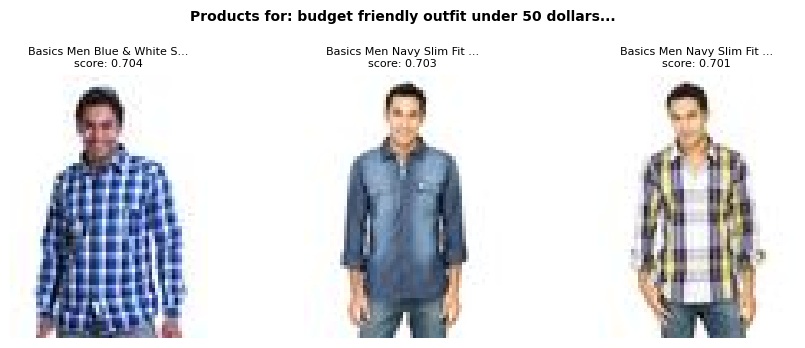

STYLEFINDER QUERY: sustainable eco-friendly clothing for a date night

LAYER 1: Style Recommendations

  Recommendation 1 (score: 0.5872):
  Profile: I'm a broad-chested, tall man with a love for classic, refined clothing. I wear well-fitted suits and crisp dress shirts...
  Occasion: I'm going to a casual date.
  Top Outfit: For a broad-chested, tall man with a love for classic, refined clothing, here are five outfit combinations for a casual date:

1. Outfit:
   - Top: Navy blue polo shirt with a crisp collar.
   - Bottom: Slim-fit chinos in a light khaki color.
   - Shoe: Brown leather loafers.
   - Accessories: A leather belt in a matching brown shade and a sleek silver watch.

  Recommendation 2 (score: 0.5855):
  Profile: I'm a man with a straight up and down body type and broad shoulders. I prefer a casual, laidback masculine style. I feel...
  Occasion: I'm going to a fancy date.
  Top Outfit: For your fancy date, I recommend the following outfit combinations:

Outfit 1:
- Top:

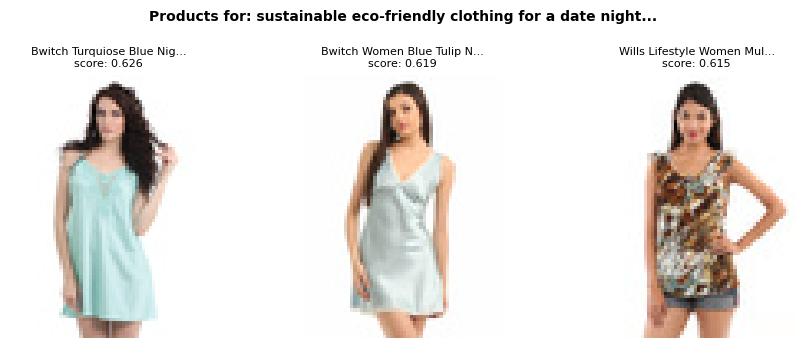

In [29]:
adversarial_queries = [
    "outfit for wheelchair user at a formal event",
    "budget friendly outfit under 50 dollars",
    "sustainable eco-friendly clothing for a date night",
]

for q in adversarial_queries:
    stylefinder(q, n_styles=2, n_products=3)